# Actividad evaluada: DESeq simplificado

Este notebook ejecuta un análisis básico de expresión diferencial con PyDESeq2.

Objetivo:

- Comparar `treated` versus `control`.
- Identificar genes diferencialmente expresados.
- Crear una tabla de resultados, volcano plot y heatmap.
- Interpretar los genes usando `gene_metadata.csv`.

## 0. Configuración

Edita solamente esta celda si necesitas cambiar de dataset o ajustar umbrales.

In [1]:
import os
from pathlib import Path

# -------------------------------------------------------------------
# EDITAR ESTAS VARIABLES
# -------------------------------------------------------------------
GROUP_DATASET = "dataset_grupo_A"  # cambiar por dataset_grupo_A ... dataset_grupo_K

# Si el notebook se ejecuta desde la raíz del repositorio, esto funciona sin cambios.
PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "actividad_evaluada").exists():
    PROJECT_DIR = PROJECT_DIR.parent

DATASET_DIR = PROJECT_DIR / "actividad_evaluada" / GROUP_DATASET / "counts"
COUNTS_FILE = DATASET_DIR / "counts_matrix.csv"
METADATA_FILE = DATASET_DIR / "metadata.csv"
GENE_METADATA_FILE = DATASET_DIR / "gene_metadata.csv"
RESULTS_DIR = DATASET_DIR / "results"

CONDITION_COL = "condition"
CONTRAST = ("treated", "control")  # log2FC = treated / control
FDR_THRESHOLD = 0.05
LFC_THRESHOLD = 1.0

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Dataset       : {GROUP_DATASET}")
print(f"Counts        : {COUNTS_FILE}  exists={COUNTS_FILE.exists()}")
print(f"Metadata      : {METADATA_FILE}  exists={METADATA_FILE.exists()}")
print(f"Gene metadata : {GENE_METADATA_FILE}  exists={GENE_METADATA_FILE.exists()}")
print(f"Results       : {RESULTS_DIR}")
print(f"Contrast      : {CONTRAST[0]} / {CONTRAST[1]}")

Dataset       : dataset_grupo_A
Counts        : /Users/fmelis/Documents/Colabs/clases_sistemas_microbiologicos/clases-sistemas-microbiologicos/actividad_evaluada/dataset_grupo_A/counts/counts_matrix.csv  exists=True
Metadata      : /Users/fmelis/Documents/Colabs/clases_sistemas_microbiologicos/clases-sistemas-microbiologicos/actividad_evaluada/dataset_grupo_A/counts/metadata.csv  exists=True
Gene metadata : /Users/fmelis/Documents/Colabs/clases_sistemas_microbiologicos/clases-sistemas-microbiologicos/actividad_evaluada/dataset_grupo_A/counts/gene_metadata.csv  exists=True
Results       : /Users/fmelis/Documents/Colabs/clases_sistemas_microbiologicos/clases-sistemas-microbiologicos/actividad_evaluada/dataset_grupo_A/counts/results
Contrast      : treated / control


## 1. Cargar datos

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

counts = pd.read_csv(COUNTS_FILE, index_col="gene_id")
metadata = pd.read_csv(METADATA_FILE).set_index("sample_id")
gene_metadata = pd.read_csv(GENE_METADATA_FILE).set_index("gene_id")

# Alinear muestras entre matriz de conteos y metadata
common_samples = [sample for sample in counts.columns if sample in metadata.index]
counts = counts[common_samples]
metadata = metadata.loc[common_samples]

print(f"Counts: {counts.shape[0]} genes x {counts.shape[1]} samples")
print(f"Metadata: {metadata.shape[0]} samples x {metadata.shape[1]} columns")
print("Condiciones:")
print(metadata[CONDITION_COL].value_counts())
counts.head()

Counts: 60 genes x 6 samples
Metadata: 6 samples x 5 columns
Condiciones:
condition
control    3
treated    3
Name: count, dtype: int64


,ctrl_1,ctrl_2,ctrl_3,treat_1,treat_2,treat_3
gene_id,,,,,,
GENE_0051,301,342,477,2091,1202,3000
GENE_0061,277,90,300,616,634,2573
GENE_0078,43,17,96,338,101,560
GENE_0091,69,101,44,259,489,784
GENE_0098,209,148,235,283,1173,1813


In [3]:
metadata

,condition,replicate,culture_medium,incubation_h,sequencing_batch
sample_id,,,,,
ctrl_1,control,1,rich_glucose,24,batch_1
ctrl_2,control,2,rich_glucose,24,batch_1
ctrl_3,control,3,rich_glucose,24,batch_2
treat_1,treated,1,nitrogen_limited,24,batch_1
treat_2,treated,2,nitrogen_limited,24,batch_1
treat_3,treated,3,nitrogen_limited,24,batch_2


## 2. Exploración rápida

Antes del modelo, revisamos tamaños de librería y PCA.

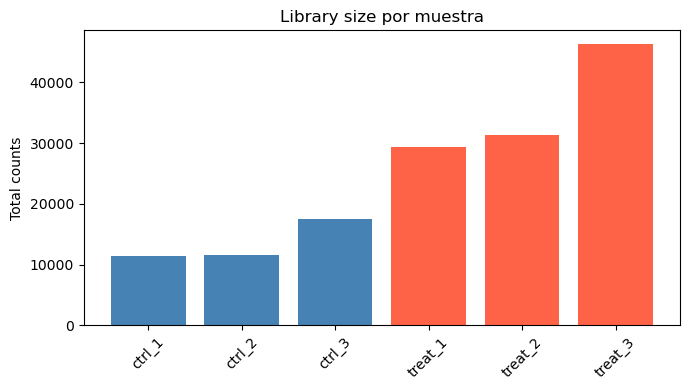

,total_counts,condition
ctrl_1,11471,control
ctrl_2,11641,control
ctrl_3,17560,control
treat_1,29277,treated
treat_2,31281,treated
treat_3,46243,treated


In [4]:
library_sizes = counts.sum(axis=0)
condition_palette = {"control": "steelblue", "treated": "tomato"}
colors = metadata.loc[library_sizes.index, CONDITION_COL].map(condition_palette)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(library_sizes.index, library_sizes.values, color=colors)
ax.set_ylabel("Total counts")
ax.set_title("Library size por muestra")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

library_sizes.to_frame("total_counts").join(metadata[[CONDITION_COL]])

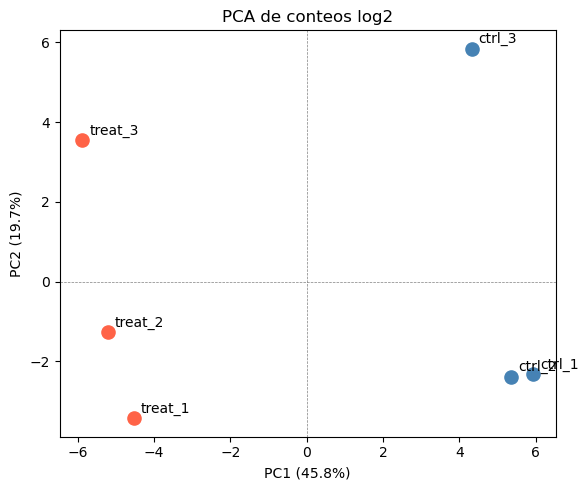

In [5]:
# Normalización simple para PCA: log2(count + 1) y escalamiento por gen
log_counts = np.log2(counts + 1)
X = StandardScaler().fit_transform(log_counts.T)
pca = PCA(n_components=2)
coords = pca.fit_transform(X)
explained = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(6, 5))
for i, sample in enumerate(counts.columns):
    condition = metadata.loc[sample, CONDITION_COL]
    ax.scatter(coords[i, 0], coords[i, 1], color=condition_palette[condition], s=90)
    ax.annotate(sample, (coords[i, 0], coords[i, 1]), xytext=(5, 4), textcoords="offset points")

ax.axhline(0, color="gray", lw=0.5, ls="--")
ax.axvline(0, color="gray", lw=0.5, ls="--")
ax.set_xlabel(f"PC1 ({explained[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({explained[1]:.1f}%)")
ax.set_title("PCA de conteos log2")
plt.tight_layout()
plt.show()

## 3. Ejecutar PyDESeq2

El modelo usado es:

```text
count ~ condition
```

El contraste es `treated / control`, por lo tanto:

- `log2FoldChange > 0`: mayor expresión en `treated`.
- `log2FoldChange < 0`: menor expresión en `treated`.

In [6]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

counts_for_deseq = counts.T

dds = DeseqDataSet(
    counts=counts_for_deseq,
    metadata=metadata,
    design=f"~{CONDITION_COL}",
    refit_cooks=True,
    quiet=False,
)

dds.deseq2()
print("Modelo DESeq2 ajustado")

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.



Modelo DESeq2 ajustado


Fitting dispersions...
... done in 0.03 seconds.

Fitting dispersion trend curve...
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.03 seconds.

Fitting LFCs...
... done in 0.02 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.



In [7]:
stat_res = DeseqStats(
    dds,
    contrast=(CONDITION_COL, CONTRAST[0], CONTRAST[1]),
    alpha=FDR_THRESHOLD,
)
stat_res.summary()

results = stat_res.results_df.copy()
results_annotated = results.join(gene_metadata, how="left")
results_annotated.head()

Log2 fold change & Wald test p-value: condition treated vs control
              baseMean  log2FoldChange     lfcSE      stat        pvalue  \
gene_id                                                                    
GENE_0051  1170.464416        2.318950  0.378344  6.129206  8.831852e-10   
GENE_0061   649.831840        2.236298  0.511979  4.367949  1.254189e-05   
GENE_0078   176.515821        2.619490  0.626844  4.178856  2.929796e-05   
GENE_0091   265.902649        2.448611  0.521359  4.696596  2.645334e-06   
GENE_0098   566.324321        2.150058  0.483027  4.451214  8.538628e-06   
GENE_0109   207.127761        1.650970  0.524803  3.145887  1.655842e-03   
GENE_0135   683.476224        2.058788  0.504477  4.081034  4.483570e-05   
GENE_0177  2710.821200        3.375922  0.362557  9.311431  1.261216e-20   
GENE_0180  1613.084493        3.236397  0.402188  8.046986  8.485804e-16   
GENE_0196  1409.893618        3.027621  0.329869  9.178244  4.381774e-20   
GENE_0199   716.05439

Running Wald tests...
... done in 0.02 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,locus_tag,gene_symbol,product,functional_category,pathway,interpretation_hint,annotation_source
gene_id,,,,,,,,,,,,,
GENE_0051,1170.464416,2.318950,0.378344,6.129206,8.831852e-10,8.831852e-09,SIM_RS00051,gln051,Glutamine synthetase family enzyme,amino acid metabolism,nitrogen assimilation,Supports assimilation of limited nitrogen sources,synthetic_teaching_annotation
GENE_0061,649.831840,2.236298,0.511979,4.367949,1.254189e-05,4.426548e-05,SIM_RS00061,ure061,Urea utilization protein,energy and nutrient metabolism,nitrogen acquisition,Suggests activation of alternative nitrogen up...,synthetic_teaching_annotation
GENE_0078,176.515821,2.619490,0.626844,4.178856,2.929796e-05,9.765988e-05,SIM_RS00078,nar078,Nitrate transporter-associated protein,transport,nitrogen acquisition,Transport candidate induced by nitrogen limita...,synthetic_teaching_annotation
GENE_0091,265.902649,2.448611,0.521359,4.696596,2.645334e-06,1.322667e-05,SIM_RS00091,gln091,Glutamine synthetase family enzyme,amino acid metabolism,nitrogen assimilation,Supports assimilation of limited nitrogen sources,synthetic_teaching_annotation
GENE_0098,566.324321,2.150058,0.483027,4.451214,8.538628e-06,3.415451e-05,SIM_RS00098,amt098,Ammonium transporter,transport,nitrogen acquisition,Higher expression suggests increased nitrogen ...,synthetic_teaching_annotation


## 4. Genes significativos

In [8]:
sig_genes = results_annotated[
    (results_annotated["padj"] < FDR_THRESHOLD) &
    (results_annotated["log2FoldChange"].abs() > LFC_THRESHOLD)
].sort_values("padj")

print(f"Genes significativos: {len(sig_genes)}")
print(f"  Up en treated: {(sig_genes['log2FoldChange'] > 0).sum()}")
print(f"  Down en treated: {(sig_genes['log2FoldChange'] < 0).sum()}")

sig_genes[[
    "gene_symbol", "product", "functional_category", "pathway",
    "log2FoldChange", "pvalue", "padj", "interpretation_hint"
]].head(15)

Genes significativos: 26
  Up en treated: 15
  Down en treated: 11


,gene_symbol,product,functional_category,pathway,log2FoldChange,pvalue,padj,interpretation_hint
gene_id,,,,,,,,
GENE_0177,ntr177,Nitrogen regulatory protein,regulation,nitrogen response,3.375922,1.261216e-20,7.567294e-19,Candidate regulator activated during nitrogen ...
GENE_0196,nas196,Nitrate/nitrite assimilation protein,energy and nutrient metabolism,nitrogen assimilation,3.027621,4.381774e-20,1.314532e-18,Consistent with use of alternative nitrogen so...
GENE_0235,gln235,Glutamine synthetase family enzyme,amino acid metabolism,nitrogen assimilation,2.811513,2.911681e-19,5.823362e-18,Supports assimilation of limited nitrogen sources
GENE_0250,amt250,Ammonium transporter,transport,nitrogen acquisition,3.249888,7.646457e-19,1.146969e-17,Higher expression suggests increased nitrogen ...
GENE_0180,nas180,Nitrate/nitrite assimilation protein,energy and nutrient metabolism,nitrogen assimilation,3.236397,8.485804e-16,1.018297e-14,Consistent with use of alternative nitrogen so...
GENE_0051,gln051,Glutamine synthetase family enzyme,amino acid metabolism,nitrogen assimilation,2.318950,8.831852e-10,8.831852e-09,Supports assimilation of limited nitrogen sources
GENE_0199,gst199,Glutathione transferase-like stress protein,stress response,oxidative stress response,2.744188,1.279242e-09,1.096493e-08,Stress-associated response during nutrient lim...
GENE_0100,dna100,DNA replication protein,replication and repair,DNA replication,-3.545983,5.389723e-09,4.042292e-08,Reduced replication-associated expression sugg...
GENE_0184,dna184,DNA replication protein,replication and repair,DNA replication,-3.000471,1.234562e-07,8.230416e-07,Reduced replication-associated expression sugg...


In [9]:
results_annotated.to_csv(RESULTS_DIR / "deseq_results_all_annotated.csv")
sig_genes.to_csv(RESULTS_DIR / "deseq_results_significant_annotated.csv")
print("Resultados guardados en:", RESULTS_DIR)

Resultados guardados en: /Users/fmelis/Documents/Colabs/clases_sistemas_microbiologicos/clases-sistemas-microbiologicos/actividad_evaluada/dataset_grupo_A/counts/results


## 5. Volcano plot

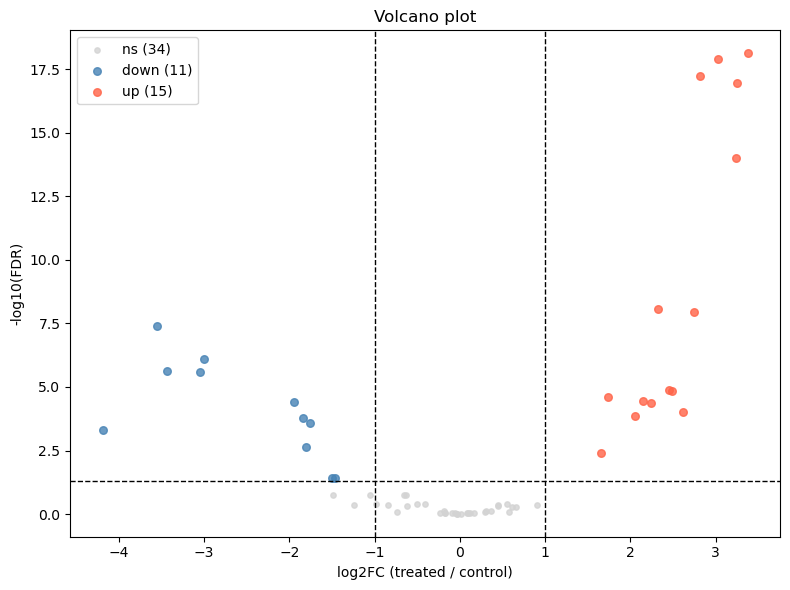

In [10]:
plot_df = results_annotated.dropna(subset=["padj", "log2FoldChange"]).copy()
plot_df["neg_log10_padj"] = -np.log10(plot_df["padj"].clip(lower=1e-300))

conditions = [
    (plot_df["padj"] < FDR_THRESHOLD) & (plot_df["log2FoldChange"] > LFC_THRESHOLD),
    (plot_df["padj"] < FDR_THRESHOLD) & (plot_df["log2FoldChange"] < -LFC_THRESHOLD),
]
plot_df["category"] = np.select(conditions, ["up", "down"], default="ns")
colors = {"up": "tomato", "down": "steelblue", "ns": "lightgray"}

fig, ax = plt.subplots(figsize=(9, 7))
for category in ["ns", "down", "up"]:
    sub = plot_df[plot_df["category"] == category]
    ax.scatter(
        sub["log2FoldChange"],
        sub["neg_log10_padj"],
        color=colors[category],
        s=35 if category != "ns" else 15,
        alpha=0.8,
        label=f"{category} ({len(sub)})",
    )

# Label all significant up/down genes (red and blue points).
labeled = plot_df[plot_df["category"].isin(["up", "down"])].copy()
for gene_id, row in labeled.iterrows():
    label = row.get("gene_symbol")
    if pd.isna(label) or label == "":
        label = gene_id
    x_offset = 5 if row["log2FoldChange"] >= 0 else -5
    ha = "left" if row["log2FoldChange"] >= 0 else "right"
    ax.annotate(
        label,
        (row["log2FoldChange"], row["neg_log10_padj"]),
        xytext=(x_offset, 2),
        textcoords="offset points",
        fontsize=8,
        ha=ha,
        va="bottom",
    )

ax.axhline(-np.log10(FDR_THRESHOLD), color="black", ls="--", lw=1)
ax.axvline(LFC_THRESHOLD, color="black", ls="--", lw=1)
ax.axvline(-LFC_THRESHOLD, color="black", ls="--", lw=1)
ax.set_xlabel(f"log2FC ({CONTRAST[0]} / {CONTRAST[1]})")
ax.set_ylabel("-log10(FDR)")
ax.set_title("Volcano plot")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Heatmap

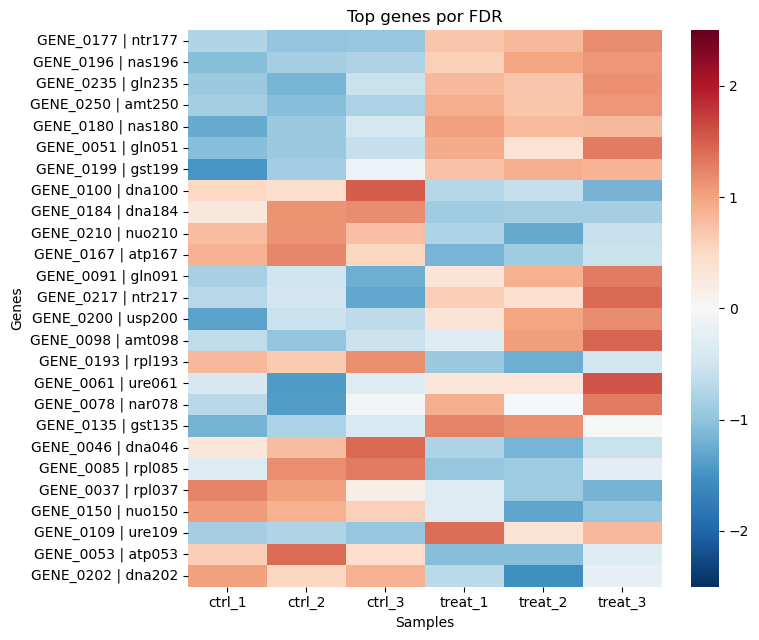

In [11]:
top_genes = sig_genes.head(30).index.tolist()
if len(top_genes) == 0:
    top_genes = results_annotated.dropna(subset=["padj"]).sort_values("padj").head(30).index.tolist()

heatmap_data = log_counts.loc[top_genes]
heatmap_z = heatmap_data.subtract(heatmap_data.mean(axis=1), axis=0)
heatmap_z = heatmap_z.divide(heatmap_data.std(axis=1).replace(0, 1), axis=0)

row_labels = [
    f"{gene} | {gene_metadata.loc[gene, 'gene_symbol']}"
    if gene in gene_metadata.index else gene
    for gene in heatmap_z.index
]
heatmap_z.index = row_labels

plt.figure(figsize=(8, max(5, len(top_genes) * 0.25)))
sns.heatmap(heatmap_z, cmap="RdBu_r", center=0, vmin=-2.5, vmax=2.5)
plt.title("Top genes por FDR")
plt.xlabel("Samples")
plt.ylabel("Genes")
plt.tight_layout()
plt.show()

## 7. Resumen para responder

Completa estas respuestas en tu informe:

1. ¿Cuál fue el contraste analizado?
2. ¿Cuántos genes fueron significativos?
3. ¿Cuántos genes subieron y cuántos bajaron en `treated`?
4. ¿Cuáles son los 3 genes más significativos?
5. ¿Qué funciones o pathways aparecen entre los genes significativos?
6. ¿Qué interpretación biológica propones para el tratamiento?